<a href="https://colab.research.google.com/github/issacridhin/LabWorks/blob/LLM/2348546_LLM_Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import WordNetLemmatizer
import re

In [ ]:
df=pd.read_csv('/content/legal_text_classification.csv')
df.head()

,case_id,case_outcome,case_title,case_text
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...,Ordinarily that discretion will be exercised s...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...,The general principles governing the exercise ...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...,Ordinarily that discretion will be exercised s...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...,The general principles governing the exercise ...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...,The preceding general principles inform the ex...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24985 entries, 0 to 24984
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   case_id       24985 non-null  object
 1   case_outcome  24985 non-null  object
 2   case_title    24985 non-null  object
 3   case_text     24809 non-null  object
dtypes: object(4)
memory usage: 780.9+ KB


In [ ]:
df.describe()

,case_id,case_outcome,case_title,case_text
count,24985,24985,24985,24809
unique,24985,10,18581,17920
top,Case1,cited,Minister for Immigration and Ethnic Affairs v ...,submitted that this Court should hold that the...
freq,1,12219,70,42


In [ ]:
df['case_outcome'].unique()

array(['cited', 'applied', 'followed', 'referred to', 'related',
       'considered', 'discussed', 'distinguished', 'affirmed', 'approved'],
      dtype=object)

In [ ]:
df.isnull().sum()

,0
case_id,0
case_outcome,0
case_title,0
case_text,47


In [ ]:
df.dropna(inplace=True)

In [ ]:
df=df[:5000]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4953 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   case_id       4953 non-null   object
 1   case_outcome  4953 non-null   object
 2   case_title    4953 non-null   object
 3   case_text     4953 non-null   object
dtypes: object(4)
memory usage: 193.5+ KB


Tokenization

In [ ]:
# Preprocessing
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    tokens = text.split()  # Tokenize
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

In [ ]:
df['process_text'] = df['case_text'].apply(preprocess_text)
df.head()

,case_id,case_outcome,case_title,case_text,process_text
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...,Ordinarily that discretion will be exercised s...,"[ordinarily, discretion, exercised, cost, foll..."
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...,The general principles governing the exercise ...,"[general, principle, governing, exercise, disc..."
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...,Ordinarily that discretion will be exercised s...,"[ordinarily, discretion, exercised, cost, foll..."
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...,The general principles governing the exercise ...,"[general, principle, governing, exercise, disc..."
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...,The preceding general principles inform the ex...,"[preceding, general, principle, inform, exerci..."


Encoding

In [ ]:
#word embeddings
model = Word2Vec(sentences=df['process_text'], vector_size=100, window=5, min_count=1, workers=4)

# Save the model if needed
model.save("word2vec_model")

In [ ]:
# Encode the tokenized text by averaging word vectors for each case
def encode_text(tokenized_text):
    vectors = [model.wv[word] for word in tokenized_text if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

df['encoded_text'] = df['process_text'].apply(encode_text)

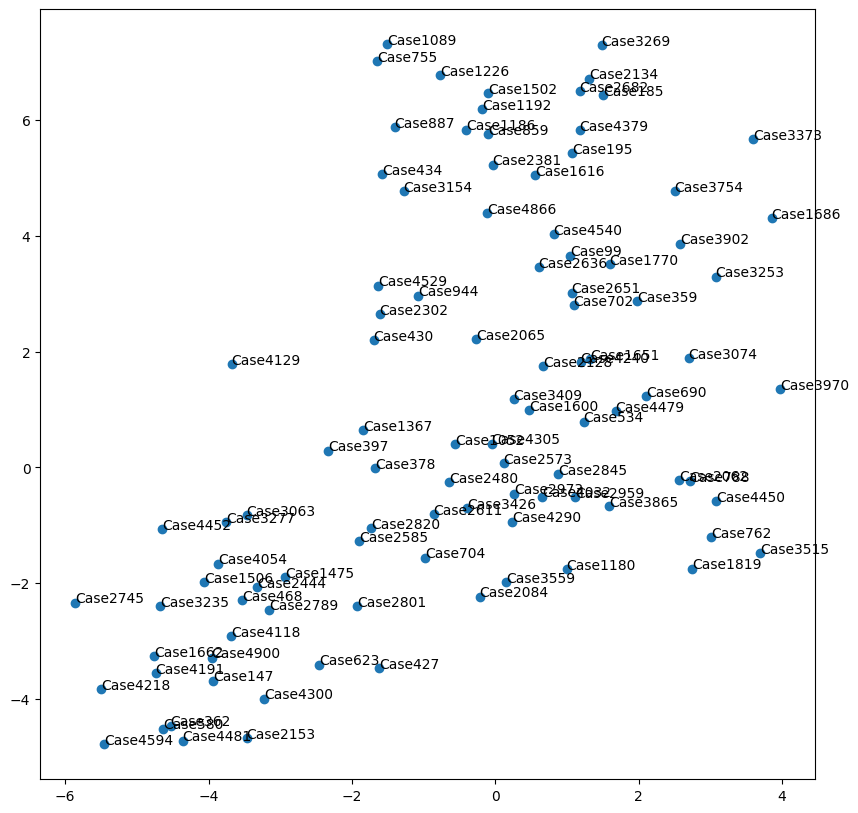

In [ ]:
def visualize_embeddings(encoded_texts, labels, limit=100):
    # Reduce the dataset to 100
    if len(encoded_texts) > limit:
        indices = np.random.choice(len(encoded_texts), size=limit, replace=False)
        encoded_texts = encoded_texts[indices]
        labels = labels[indices]

    # Apply t-SNE to reduce dimensions
    tsne = TSNE(n_components=2, random_state=0)
    Y = tsne.fit_transform(encoded_texts)

    # Plot the embeddings
    plt.figure(figsize=(10, 10))
    plt.scatter(Y[:, 0], Y[:, 1])

    # Annotate the plot with labels (if too many points, limit the annotations)
    for label, x, y in zip(labels, Y[:, 0], Y[:, 1]):
        plt.annotate(label, xy=(x, y), xytext=(0, 0), textcoords='offset points')

    # Display the plot
    plt.show()

# Prepare data for visualization
encoded_texts = np.vstack(df['encoded_text'].values)
labels = df['case_id'].values

# Visualize the embeddings with a limit of 100 points
visualize_embeddings(encoded_texts, labels, limit=100)

Visualization of vectors based on the content inside.

case1089 and case755 are near each other in this vector space, it indicates that the content of these cases is similar or shares common features.
